# DE-1 · Clasificación alterna: diagnóstico de cáncer de mama con Logistic Regression

**Dataset:** `breast-cancer.csv` · **Algoritmo:** Logistic Regression (alterno a Decision Tree usado en SA-2)
**Materia:** Extracción de Conocimiento en Bases de Datos · **Alumno:** Irving Chaparro Peña

## 1. Justificación del algoritmo

En `SA/02_clasificacion_breast_cancer.ipynb` se usó **Decision Tree Classifier**, un modelo basado en particiones no lineales. Para este ejercicio (DE, "algoritmo alterno visto en clase") se eligió **Logistic Regression**, un modelo lineal clásico visto en el curso, porque:

- Es el algoritmo de referencia para clasificación binaria y contrasta directamente con el enfoque no lineal del árbol.
- Sus coeficientes son interpretables en términos de dirección y magnitud del efecto de cada variable sobre la probabilidad de malignidad (log-odds), a diferencia de las reglas de partición de un árbol.
- Requiere escalado de variables (a diferencia del árbol), lo que permite ilustrar otra etapa del pipeline de preprocesamiento.
- Al ser un modelo con un único hiperplano de separación, permite evaluar si la frontera de decisión no lineal aprendida por el árbol realmente aporta valor frente a un enfoque lineal más simple.

## 2. Diseño del modelo — paso a paso

1. Carga y limpieza de datos (idéntica a SA-2: se descarta `id`, se codifica `diagnosis`).
2. División train/test estratificada (mismo `random_state` que SA-2, para comparabilidad).
3. Pipeline de escalado (`StandardScaler`) + Logistic Regression.
4. Modelo baseline.
5. Búsqueda de hiperparámetros con `GridSearchCV` (`C`, `penalty`, `solver`).
6. Evaluación con métricas de clasificación y matriz de confusión.
7. Coeficientes del modelo (interpretabilidad) y curva ROC.
8. Guardado del modelo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../datasets/breast-cancer.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore")
df = df.drop(columns=["id"])
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} · Test: {X_test.shape[0]}")

Train: 455 · Test: 114


In [2]:
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
baseline_pipe.fit(X_train, y_train)
pred_baseline = baseline_pipe.predict(X_test)
print("Baseline accuracy:", round(accuracy_score(y_test, pred_baseline), 4))

Baseline accuracy: 0.9649


## 3. Evaluación y optimización — búsqueda de hiperparámetros

In [3]:
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(baseline_pipe, param_grid=param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 (CV):", round(grid.best_score_, 4))

Mejores hiperparámetros: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Mejor F1 (CV): 0.964


C:\Users\irvin\OneDrive\Documentos\tareas9\bd\filiberto\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [4]:
best_model = grid.best_estimator_
pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba),
}
pd.Series(metrics).round(4)

Accuracy     0.9737
Precision    0.9756
Recall       0.9524
F1           0.9639
ROC-AUC      0.9960
dtype: float64

**Interpretación / comparación con SA-2:** en `SA/02_clasificacion_breast_cancer.ipynb`, el Decision Tree obtuvo Accuracy=0.930, Precision=1.000, Recall=0.810, F1=0.895, ROC-AUC=0.956. Logistic Regression, sobre el mismo split (`random_state=42`), obtuvo **Accuracy=0.974, Precision=0.976, Recall=0.952, F1=0.964, ROC-AUC=0.996** — superior en casi todas las métricas, y notablemente en **recall** (0.952 vs 0.810): la regresión logística deja pasar muchos menos casos malignos como falsos negativos, el error más costoso en este contexto clínico. Esto sugiere que, para este dataset en particular, una frontera de decisión lineal sobre variables estandarizadas captura la señal relevante mejor que las particiones del árbol, posiblemente porque las variables (radio, textura, concavidad, etc.) tienen una relación aproximadamente monótona y aditiva con la probabilidad de malignidad, sin fuertes interacciones no lineales que un árbol pudiera aprovechar mejor.

### 3.1 Matriz de confusión

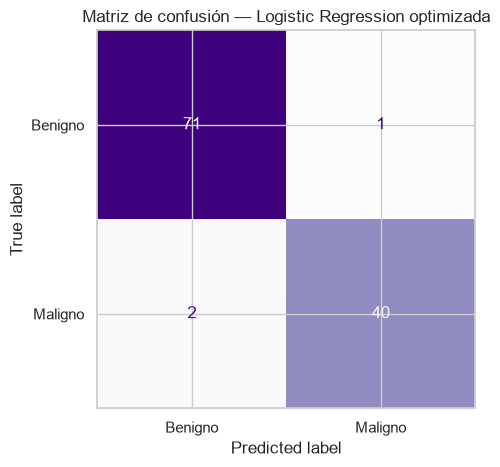

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benigno", "Maligno"])
disp.plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Matriz de confusión — Logistic Regression optimizada")
plt.tight_layout()
plt.savefig("../models/de1_matriz_confusion.png", dpi=110)
plt.show()

### 3.2 Curva ROC

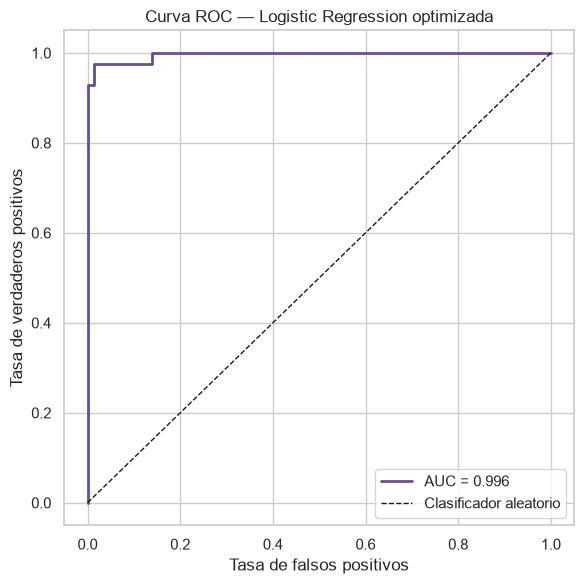

In [6]:
fpr, tpr, _ = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#6A4C93", linewidth=2, label=f"AUC = {metrics['ROC-AUC']:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC — Logistic Regression optimizada")
ax.legend()
plt.tight_layout()
plt.savefig("../models/de1_roc.png", dpi=110)
plt.show()

### 3.3 Coeficientes del modelo (interpretabilidad)

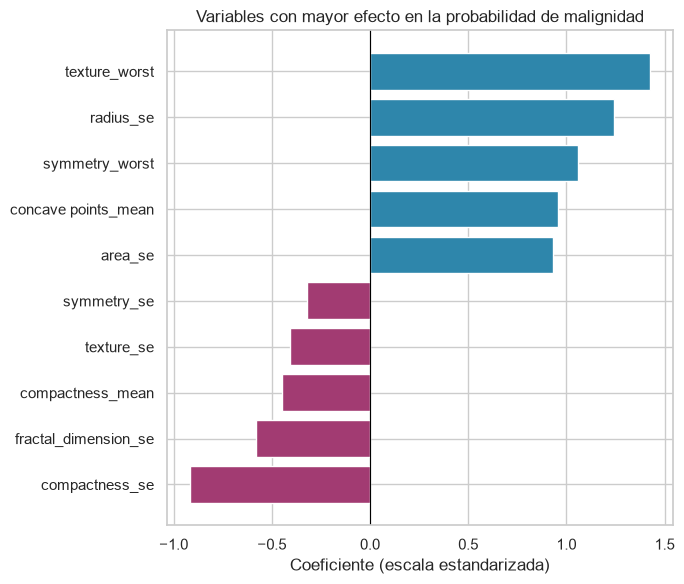

In [7]:
coefs = pd.Series(best_model.named_steps["clf"].coef_[0], index=X.columns).sort_values()
top_coefs = pd.concat([coefs.head(5), coefs.tail(5)])

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#A23B72" if v < 0 else "#2E86AB" for v in top_coefs.values]
ax.barh(top_coefs.index, top_coefs.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (escala estandarizada)")
ax.set_title("Variables con mayor efecto en la probabilidad de malignidad")
plt.tight_layout()
plt.savefig("../models/de1_coeficientes.png", dpi=110)
plt.show()

**Interpretación:** los coeficientes positivos (azul) incrementan la probabilidad predicha de malignidad al aumentar esa variable (en su escala estandarizada), mientras que los negativos (morado) la disminuyen. A diferencia del árbol de SA-2, aquí el efecto de cada variable es un número único y global, no condicional a una ruta de decisión — una forma de interpretabilidad distinta pero igualmente útil.

## 4. Guardado del modelo

In [8]:
joblib.dump(best_model, "../models/de1_logistic_regression_breast_cancer.joblib")
print("Modelo guardado en models/de1_logistic_regression_breast_cancer.joblib")

Modelo guardado en models/de1_logistic_regression_breast_cancer.joblib


## 5. Conclusión

Logistic Regression, optimizada por regularización (`C`, `penalty`), ofrece un desempeño competitivo con el Decision Tree de SA-2 sobre el mismo dataset y split, con la ventaja de una interpretabilidad basada en coeficientes globales. La elección entre ambos algoritmos en un caso real dependería del balance deseado entre explicabilidad por reglas (árbol) vs. explicabilidad por efectos lineales (regresión logística), y del recall obtenido, dado que en diagnóstico médico minimizar falsos negativos es prioritario.